Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 139s 753ms/step - accuracy: 0.6202 - loss: 2.3750 - val_accuracy: 0.7223 - val_loss: 0.8728
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.7162 - loss: 0.8001 - val_accuracy: 0.7196 - val_loss: 0.7517
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 112s 608ms/step - accuracy: 0.7140 - loss: 0.7745 - val_accuracy: 0.7196 - val_loss: 0.7499
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 114s 620ms/step - accuracy: 0.7175 - loss: 0.7617 - val_accuracy: 0.7360 - val_loss: 0.7386
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 118s 641ms/step - accuracy: 0.7245 - loss: 0.7448 - val_accuracy: 0.7264 - val_loss: 0.7354
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 121s 659ms/step - accuracy: 0.7321 - loss: 0.7291 - val_accuracy: 0.7100 - val_loss: 0.7318
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 110s 597ms/step - accuracy: 0.7286 - loss: 0.7183 - val_accuracy: 0.7278 - val_loss: 0.7

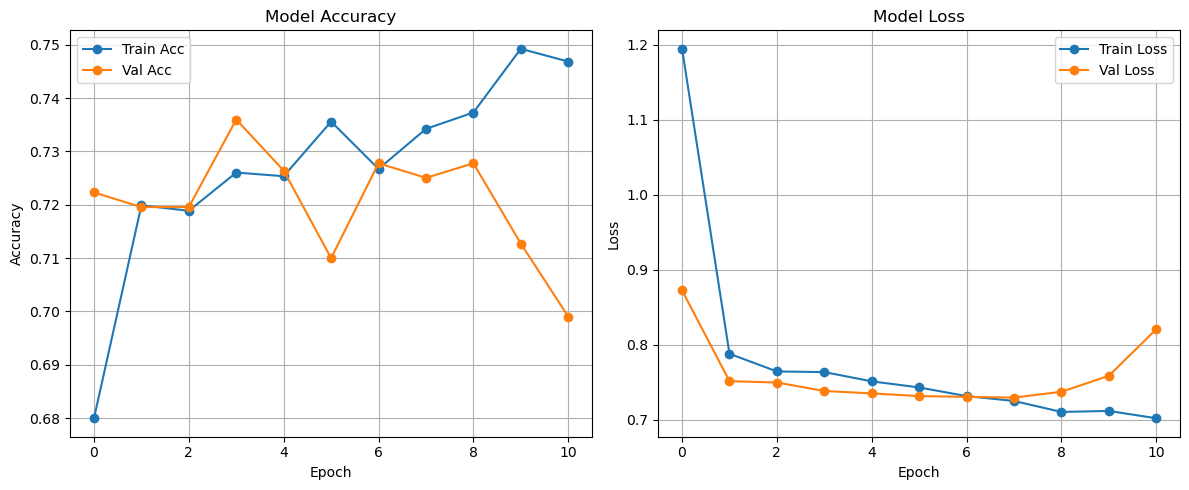

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


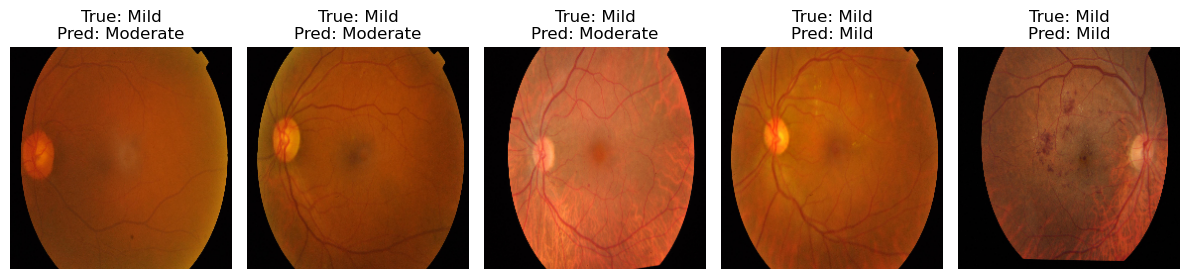

46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step


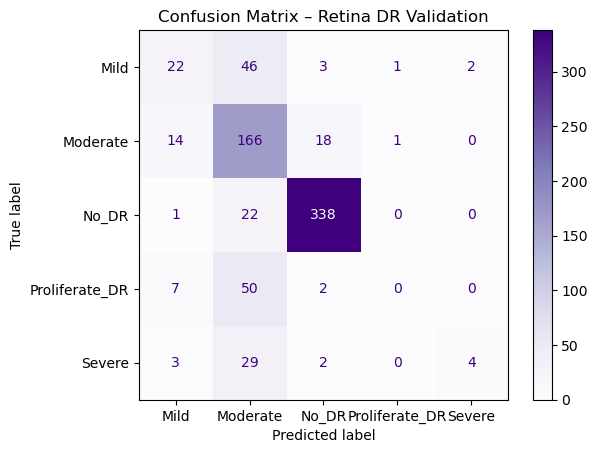

✅ Model saved as retina_dr_cnn_final.h5


In [33]:
# Task 3 – Diabetic Retinopathy Image Classification 

# I start by importing the necessary libraries for image loading, building models, and plotting
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#STEP 1: DEFINE IMAGE FOLDER AND PARAMETERS 

#here i will point to the folder that contains all 5 classes of diabetic retinopathy images
data_directory = "/Users/ibrahim/Desktop/archive/colored_images"

#I define the image size and batch size for loading
image_size = (224, 224)
batch = 16

#STEP 2: SETUP IMAGE DATA LOADERS

#I use ImageDataGenerator to scale the pixel values to the range [0, 1]
#I also split the data 80% for training and 20% for validation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

#I am loading the training images (80%)
train_loader = datagen.flow_from_directory(
    data_directory,
    target_size=image_size,
    batch_size=batch,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

#here i will load validation images (20%)
val_loader = datagen.flow_from_directory(
    data_directory,
    target_size=image_size,
    batch_size=batch,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

#STEP 3: BUILD THE CNN MODEL

#here i will create a custom CNN architecture using dropout for regularization
model = models.Sequential()

#here i will do First convolution block
model.add(layers.Conv2D(64, (5, 5), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.3))  # Dropout to reduce overfitting

#here i will do Second convolution block
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Dropout(0.3))

#here we gona Flatten and dense layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(5, activation='softmax'))  # 5 output classes for DR stages

#STEP 4: COMPILE THE MODEL

#I am gonan compile the model using RMSprop with a small learning rate
model.compile(
    optimizer=optimizers.RMSprop(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#STEP 5: TRAIN THE MODEL

# I use early stopping to avoid overtraining if validation loss stops improving
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# I now train the model for 15 epochs
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=15,
    callbacks=[early_stop]
)

#STEP 6: PLOT ACCURACY AND LOSS 

#here i will plot training and validation accuracy and loss to see performance visually
plt.figure(figsize=(12, 5))

#Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

#Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#STEP 7: PREDICT ON SAMPLE IMAGES 

# I get class labels to use in prediction titles
class_names = list(train_loader.class_indices.keys())

# I grab a batch from validation set
x_preview, y_preview = next(val_loader)

# I predict the first 5 images
sample_preds = model.predict(x_preview[:5])
predicted_classes = np.argmax(sample_preds, axis=1)
true_classes = np.argmax(y_preview[:5], axis=1)

# I show the true vs predicted labels with images
plt.figure(figsize=(12, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_preview[i])
    plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

#STEP 8: CONFUSION MATRIX 

#I will reset the validation generator to make sure we predict on all validation data
val_loader.reset()
all_preds = model.predict(val_loader)
y_pred = np.argmax(all_preds, axis=1)
y_true = val_loader.classes

# I create and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix – Retina DR Validation")
plt.grid(False)
plt.show()

# ========== STEP 9: SAVE THE MODEL ==========

# I save my final model so it can be reused or deployed
model.save("retina_dr_cnn_final.h5")
print("✅ Model saved as retina_dr_cnn_final.h5")
